# Introduction to T<sub>c</sub>1D (Inverse mode)

This is a Jupyter notebook, an interactive environment that can be used to run numerical simulations. In this notebook, we will explore how to use T<sub>c</sub>1D in inverse mode to constrain geological histories from thermochronological data.

## Inversion of thermochronological data with T<sub>c</sub>1D

Thermochronology provides quantitative constraints on the cooling history of rocks through geological time. These data can be used to infer the timing and rate of geological processes such as exhumation, erosion, and burial. However, the relationship between geological parameters (e.g., erosion history) and observed thermochronological ages is complex and non-linear.

We therefore need to solve an inverse problem: What ranges of model parameters, such as the timing and magnitude of erosion, can reproduce the observed thermochronological data?

## What is an inversion?

An inversion explores possible combinations of model parameters and evaluates how well the corresponding forward models reproduce the observations. In T<sub>c</sub>1D, observed and predicted thermochronological ages are compared to quantify the model misfit.

## Inversion methods in T<sub>c</sub>1D

This notebook illustrates two approaches implemented in T<sub>c</sub>1D for exploring the parameter space:

### 1. Neighbourhood Algorithm (NA)

* A stochastic, adaptive sampling method.
* It iteratively explores the parameter space, preferentially sampling regions associated with lower model misfit.
* It is useful for efficiently identifying regions of parameter space containing acceptable models.

### 2. Markov Chain Monte Carlo (MCMC)

* A Bayesian sampling method based on Markov chains.
* It samples the parameter space according to the probability of the models given the observations.
* It allows the probability distributions and uncertainties of model parameters to be explored, but is generally more computationally expensive.

## Objective of this notebook

We will use T<sub>c</sub>1D to perform both NA and MCMC inversions using a simple synthetic thermochronological dataset. The goal is to demonstrate how inverse models are configured and run, and how their results can be visualized and interpreted.

> **⚠️ Disclaimer**
>
> The inversions performed in this notebook are intentionally simplified and use limited model complexity and small sampling sizes to ensure rapid execution in an interactive Jupyter environment. The results are illustrative and should not be considered scientifically robust inversions of thermochronological data. Scientific applications should use appropriate model configurations, parameter ranges, and sufficient sampling to adequately explore the parameter space.

## Attribution

If you use T<sub>c</sub>1D or results produced by the software, please cite:

* Whipp, D. M., Gérard, B., Laaksonen, S., and Kellett, D. A.: Technical note: Tc1D - a 1D thermal and thermochronometer age prediction model, *EGUsphere* [preprint], https://doi.org/10.5194/egusphere-2026-2514, 2026.

The thermochronometer age-prediction routines used by T<sub>c</sub>1D were developed by Richard Ketcham and colleagues. Relevant references include:

* Ketcham, R. A., Donelick, R. A., & Carlson, W. D. (1999). Variability of apatite fission-track annealing kinetics III: Extrapolation to geological time scales. *American Mineralogist*, 84, 1235–1255. https://doi.org/10.2138/am-1999-0903
* Ketcham, R. A., Mora, A., & Parra, M. (2018). Deciphering exhumation and burial history with multi-sample down-well thermochronometric inverse modelling. *Basin Research*, 30, 48–64. https://doi.org/10.1111/bre.12207

The inversion approaches implemented in T<sub>c</sub>1D are based on methods described in:

* Sambridge, M. (1999). Geophysical inversion with a neighbourhood algorithm – I. Searching a parameter space. *Geophysical Journal International*, 138, 479–494. https://doi.org/10.1046/j.1365-246x.1999.00876.x
* Sambridge, M. (1999). Geophysical inversion with a neighbourhood algorithm – II. Appraising the ensemble. *Geophysical Journal International*, 138, 727–746. https://doi.org/10.1046/j.1365-246x.1999.00900.x
* Gilks, W. R., Richardson, S., & Spiegelhalter, D. J. (eds.) (1996). *Markov Chain Monte Carlo in Practice*. Chapman & Hall/CRC.
* Foreman-Mackey, D., Hogg, D. W., Lang, D., & Goodman, J. (2013). emcee: The MCMC Hammer. *Publications of the Astronomical Society of the Pacific*, 125, 306–312. https://doi.org/10.1086/670067



# Using this notebook

Below you will find some general information about the notebook environment and examples of how to perform inverse models using T<sub>c</sub>1D.

## Using a Jupyter notebook

A Jupyter notebook is a document that combines formatted text with executable Python code. The notebook is divided into cells containing either text or code.

To run a code cell, select the cell and press <kbd>shift</kbd> + <kbd>enter</kbd> or <kbd>shift</kbd> + <kbd>return</kbd>.

Let's test this below.

In [41]:
print(f"The sum of 22222 plus 1234 is {22222 + 1234}.")

The sum of 22222 plus 1234 is 23456.


# Preparing to run T<sub>c</sub>1D

As with a forward T<sub>c</sub>1D model, we first need to import the Python packages required in this notebook. We will use the `tc1d` package to configure and run the models, `pandas` to read and display the thermochronological data, and tools from IPython to display model outputs.

The required packages are imported below.

In [42]:
import tc1d
import pandas as pd
from IPython.display import Image, display

# Configuring an inverse model

T<sub>c</sub>1D model parameters can be defined using a YAML configuration file. YAML files provide a convenient and readable way to store the parameters required to configure and run a model.

For an inverse model, most parameters are defined in the same way as for a forward model. The main difference is that parameters to be explored during the inversion can be specified as a range of values.

For example, a fixed parameter can be defined as:

    ero_option2: 6.0

whereas a parameter to be explored during the inversion can be defined using its minimum and maximum values:

    ero_option1: [0.0, 15.0]

In this case, T<sub>c</sub>1D will treat `ero_option1` as an invertible parameter and explore values between 0 and 15 during the inversion.

This makes it possible to define both the forward-model configuration and the inverse parameter space within the same YAML input file.

In the following example, we will define a simple erosion history in which two parameters are allowed to vary while the remaining parameters are fixed.

# Synthetic thermochronological data

For this demonstration, we will use a simple synthetic dataset containing four thermochronological ages:

- 1 apatite (U-Th)/He (AHe) age,
- 1 apatite fission-track (AFT) age,
- 1 zircon (U-Th)/He (ZHe) age,
- 1 zircon fission-track (ZFT) age.

Each observation includes an age and its associated uncertainty. Additional information required for thermochronometer age prediction, such as grain radius and effective uranium concentration, is also provided where needed.

The dataset is stored in the `demo_inversion_data.csv` file and can be inspected below.

In [43]:
data_file = "demo_inversion_data.csv"

data = pd.read_csv(data_file)

data

,Age type,Age (Ma),Standard deviation (Ma),eU concentration (ppm),Grain radius (um),Sample ID,Depositional age (Ma)
0,AHe,2.74,0.3,29.3,58.0,demo1,NaN
1,AFT,5.98,0.6,NaN,NaN,demo2,NaN
2,ZHe,8.15,0.6,506.8,57.9,demo3,NaN
3,ZFT,9.80,0.9,NaN,NaN,demo4,NaN


# Defining the erosion history

For this demonstration, we use a simple two-stage erosion history.

The erosion history is controlled by four parameters:

- `ero_option1`: exhumation magnitude of the first erosion phase,
- `ero_option2`: transition time following the first erosion phase,
- `ero_option3`: exhumation magnitude of the second erosion phase,
- `ero_option4`: second transition time.

In this example, the exhumation magnitudes (`ero_option1` and `ero_option3`) are allowed to vary during the inversion, whereas the transition times (`ero_option2` and `ero_option4`) remain fixed.

The corresponding model parameters will be defined in a YAML input file below.

In [45]:
%%writefile demo_inversion.yaml

# T<sub>c</sub>1D inverse-mode demonstration configuration
#
# Main units:
# time, start times, durations : Myr
# dt                           : years
# length/depth/thickness       : km
# velocity                     : mm yr^-1
# grain radius                 : micrometres
# U, Th                        : ppm

# ==============================================================================
# 1) General / run control
# ==============================================================================
general:
  run_type: "na"               # Run mode: forward / batch / na / mcmc.
  batch_mode: false            # Internal CLI batch flag.
  inverse_mode: true           # Must be true for NA/MCMC.
  debug: false                 # Print additional debugging information.

  # Screen-output controls.
  echo_inputs: false           # Print the input parameter values.
  no_echo_info: true           # Suppress general model information.
  no_echo_thermal_info: true   # Suppress thermal-model information.
  no_echo_ages: true           # Suppress calculated thermochronometer ages.

# ==============================================================================
# 2) Geometry and time
# ==============================================================================
geometry_time:
  length: 125.0                # Model depth extent [km].
  nx: 501                      # Number of temperature grid nodes [-].
  time: 12.0                   # Total model duration [Myr].
  dt: 20000                    # Numerical time step [yr].

  init_moho_depth: 35.0        # Initial Moho depth [km].
  crustal_uplift: false        # If true, vertical motion is restricted to the crust.
  fixed_moho: true             # If true, the Moho depth is held fixed.

  removal_fraction: 0.0        # Fraction of lithospheric mantle removed [0-1].
  removal_start_time: 0.0      # Start of mantle removal [Myr after model start].
  removal_end_time: -1.0       # End of mantle removal [Myr after model start].

# ==============================================================================
# 3) Erosion / burial / vertical motion
# ==============================================================================
erosion_model:
  vx_init: 0.0                 # Initial steady-state vertical advection velocity [mm yr^-1].

  # Erosion model type 2:
  # constant-rate erosion with stepwise changes at specified times.
  #
  # The erosion rates are calculated from the exhumation magnitude
  # of each phase divided by its duration.
  ero_type: 2

  mantle_velocity: 0.0         # Mantle vertical velocity [mm yr^-1].

  # Parameters written as [min, max] are explored during the inversion.
  # Scalar parameters remain fixed.
  #
  # Phase 1:
  ero_option1: [0.0, 15.0]     # Exhumation magnitude m1 [km], inverted parameter.
  ero_option2: 6.0              # First transition time t1 [Myr].

  # Phase 2:
  ero_option3: [0.0, 15.0]     # Exhumation magnitude m2 [km], inverted parameter.
  ero_option4: 12.0             # Second transition time t2 [Myr].

# ==============================================================================
# 4) Thermochronometer age prediction
# ==============================================================================
age_prediction:
  no_calc_ages: false          # false = calculate thermochronometer ages.

  ketch_aft: true              # Use Ketcham AFT model.
  madtrax_aft: false           # Use MadTrax apatite FT model if enabled.

  madtrax_aft_kinetic_model: 1 # MadTrax apatite FT kinetic model selector.
  madtrax_zft_kinetic_model: 1 # MadTrax zircon FT kinetic model selector.

  # Default apatite grain properties used where sample-specific values are absent.
  ap_rad: 60.0                 # Apatite grain radius [micrometres].
  ap_uranium: 10.0             # Apatite U concentration [ppm].
  ap_thorium: 40.0             # Apatite Th concentration [ppm].

  # Default zircon grain properties.
  zr_rad: 60.0                 # Zircon grain radius [micrometres].
  zr_uranium: 100.0            # Zircon U concentration [ppm].
  zr_thorium: 40.0             # Zircon Th concentration [ppm].

  pad_time: 0.0                # Additional time appended at initial T [Myr].
  past_age_increment: 0.0      # <=0 disables incremental past-age calculations.

# ==============================================================================
# 5) Observations and misfit
# ==============================================================================
observations:
  obs_age_file: "demo_inversion_data.csv"  # Observed thermochronometer data.

  misfit_num_params: 0         # Number of fitted parameters; used only by misfit type 2.

  # Misfit formulation:
  #   1 = sqrt(chi-square) / N
  #   2 = reduced chi-square-like form using N-P-1
  #   3 = summed chi-square
  misfit_type: 3

# ==============================================================================
# 6) Plotting
# ==============================================================================
plotting:
  no_plot_results: false       # false = create standard result plots.
  no_display_plots: true       # false = display plots interactively.
  plot_myr: false              # false = geological time in Ma.

# ==============================================================================
# 7) Output
# ==============================================================================
output:
  model_id: "demo_inversion"   # User-defined model identifier.
  save_plots: true             # Save generated figures.

# ==============================================================================
# 8) Inversion hyperparameters
# ==============================================================================
inversion:
  neighbourhood_algorithm:
    na_ns: 30                  # Number of new NA samples per iteration.
    na_nr: 15                   # Number of Voronoi cells resampled per iteration.
    na_ni: 60                  # Initial random-search size.
    na_n: 10                    # Number of NA iterations after the initial search.
    na_n_resample: 1000        # NA appraiser resampling size.
    na_n_walkers: 4            # NA appraiser walkers.

  mcmc:
    mcmc_nwalkers: 6          # Number of emcee ensemble walkers.
    mcmc_nsteps: 100           # Number of steps per walker.
    mcmc_discard: 0            # Burn-in steps discarded before analysis.
    mcmc_thin: 1               # Chain thinning factor.

Overwriting demo_inversion.yaml


# Running the Neighbourhood Algorithm inversion

Now that the model configuration and inversion parameters have been defined in the YAML input file, we can run T<sub>c</sub>1D.

Because the YAML file already contains the model configuration, observed-data file, parameter ranges, and Neighbourhood Algorithm settings, only the input-file path needs to be provided.

The cell below therefore runs the complete NA inversion using the `demo_inversion.yaml` configuration created above.

> **⏱️ Runtime:** This demonstration uses relatively small sampling settings so that the inversion can be run interactively. Depending on the computer and notebook environment, the calculation may take a few minutes.

In [46]:
!tc1d-cli --input-file demo_inversion.yaml


========================== This is Tc1D version 0.4.1 ==========================

--------------------------- Starting NA inverse mode ---------------------------

NAI - Initial Random Search
The current values are: {'ero_option1': 0.3448762999378019, 'ero_option3': 7.298044407063163}
The current misfit is: 11.058438873377927

The current values are: {'ero_option1': 8.153606286577853, 'ero_option3': 1.4229095961210736}
The current misfit is: 259.8530981604975

The current values are: {'ero_option1': 5.939953817414964, 'ero_option3': 2.156984534980822}
The current misfit is: 264.671259414413

The current values are: {'ero_option1': 6.682328739083595, 'ero_option3': 4.98753153494644}
The current misfit is: 12.822852360362113

The current values are: {'ero_option1': 12.78128869089163, 'ero_option3': 9.984223943590399}
The current misfit is: 135.24076501918117

The current values are: {'ero_option1': 10.07941012377636, 'ero_option3': 8.32757538440167}
The current misfit is: 69.68542218247

# Exploring the NA inversion results

The Neighbourhood Algorithm inversion has now explored the parameter space defined in the YAML input file and identified combinations of erosion parameters that reproduce the synthetic thermochronological observations with different levels of misfit.

During the inversion, T<sub>c</sub>1D automatically generates several diagnostic plots that can be used to inspect the parameter-space exploration and the resulting model ensemble:

- **Misfit plot** - shows how model misfit varies among the sampled models.
- **Sample scatter plot** - shows the distribution of sampled models within the parameter space.
- **Covariance matrix** - illustrates relationships and correlations between the inverted parameters.
- **Voronoi diagram** - visualizes the adaptive sampling of parameter space by the Neighbourhood Algorithm.
- **Parameter histograms** - show the distributions of the sampled parameter values.

For this demonstration, the two inverted parameters correspond to the exhumation magnitudes of the two erosion phases (`ero_option1` and `ero_option3`).

The plots generated by T<sub>c</sub>1D are displayed below.

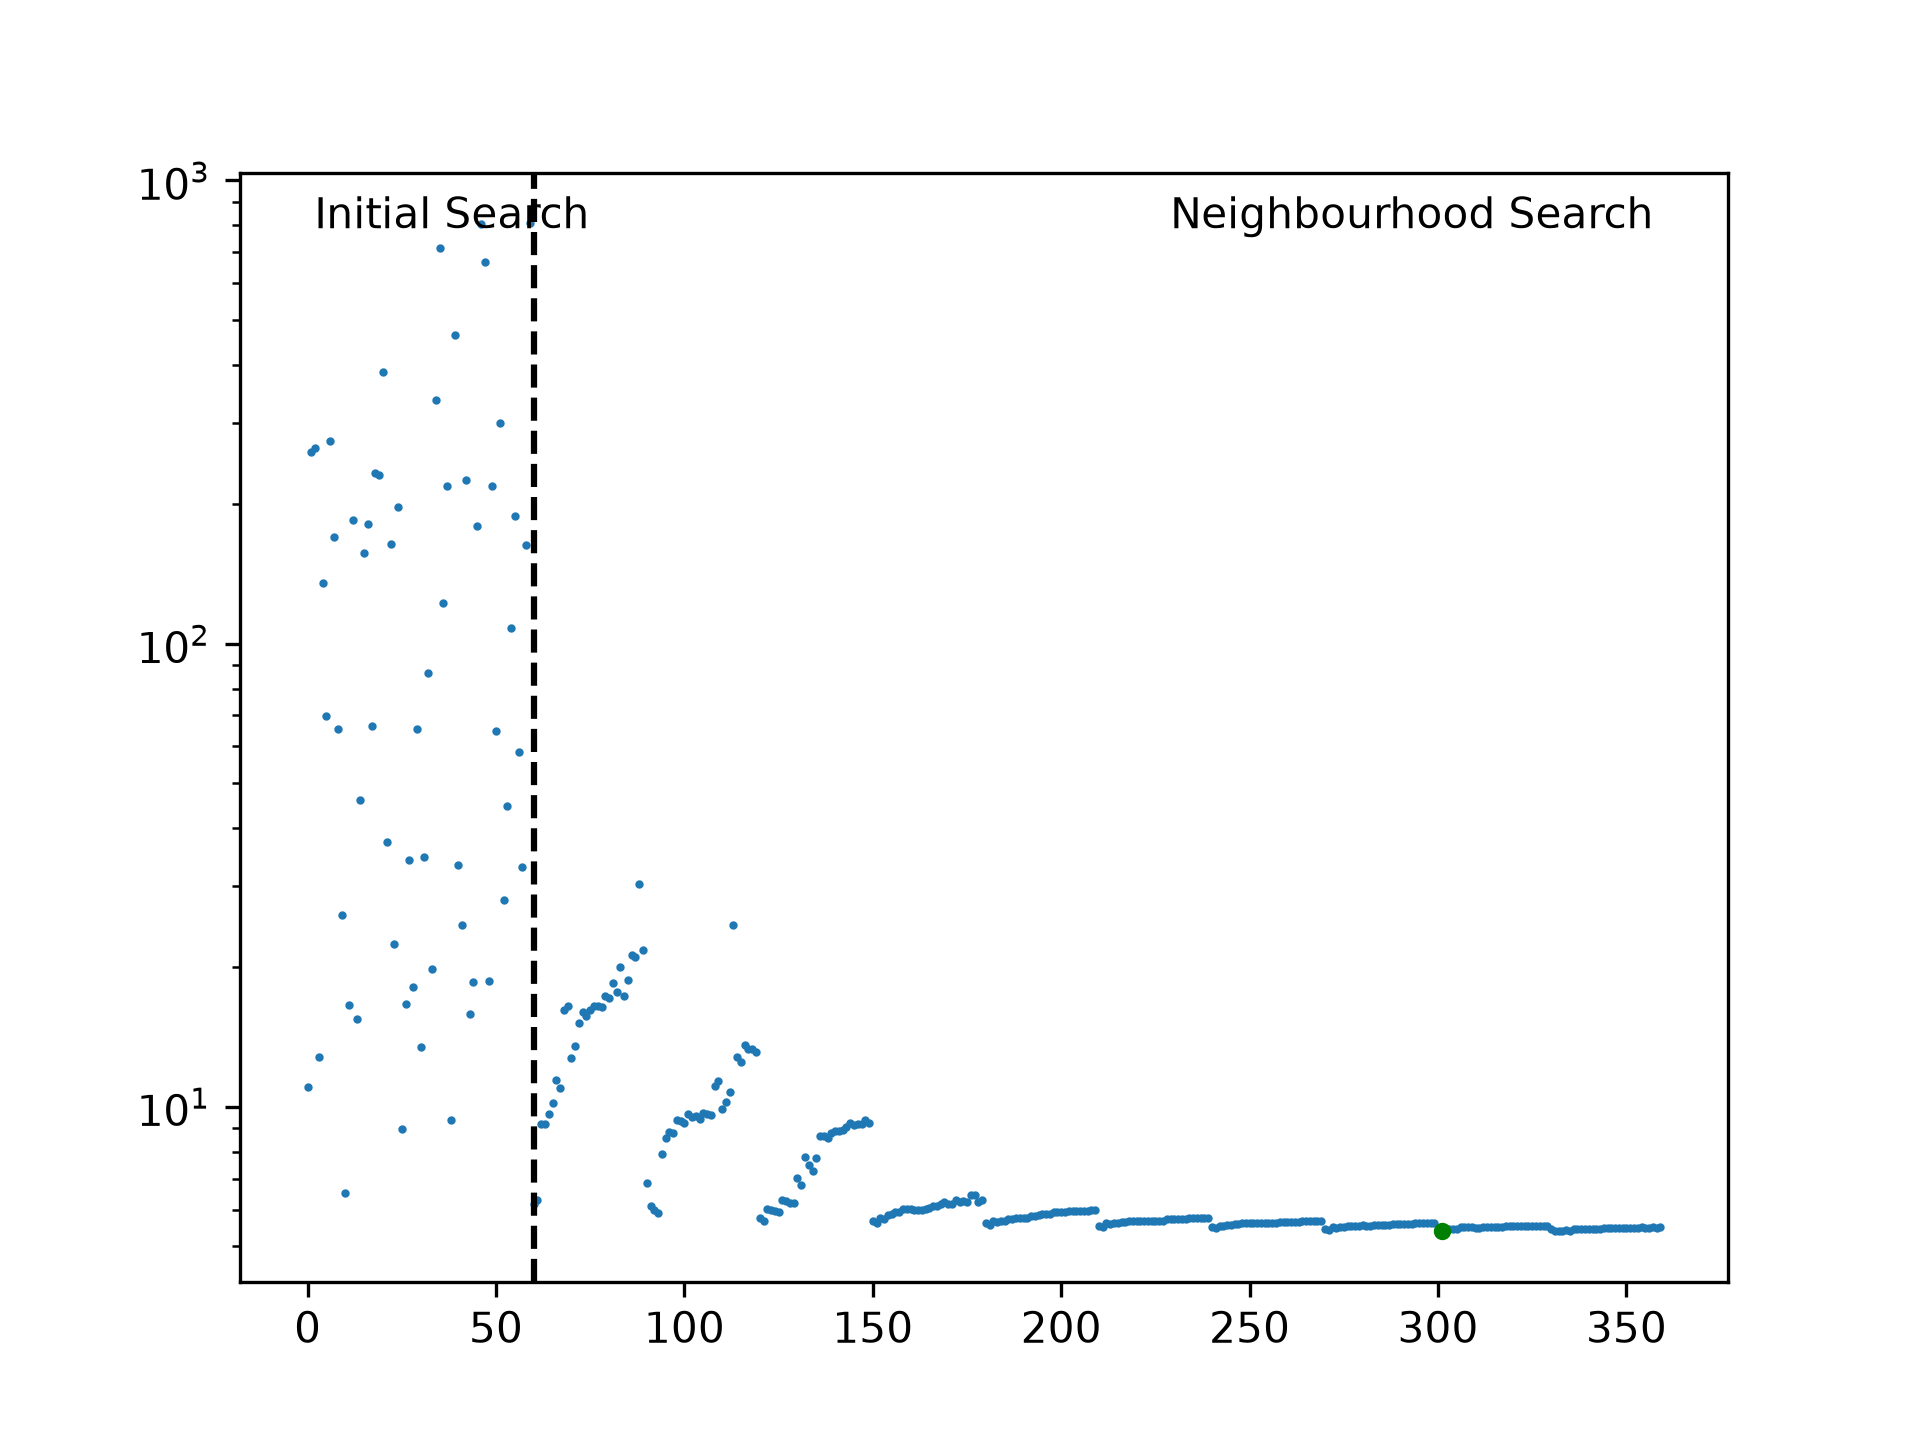

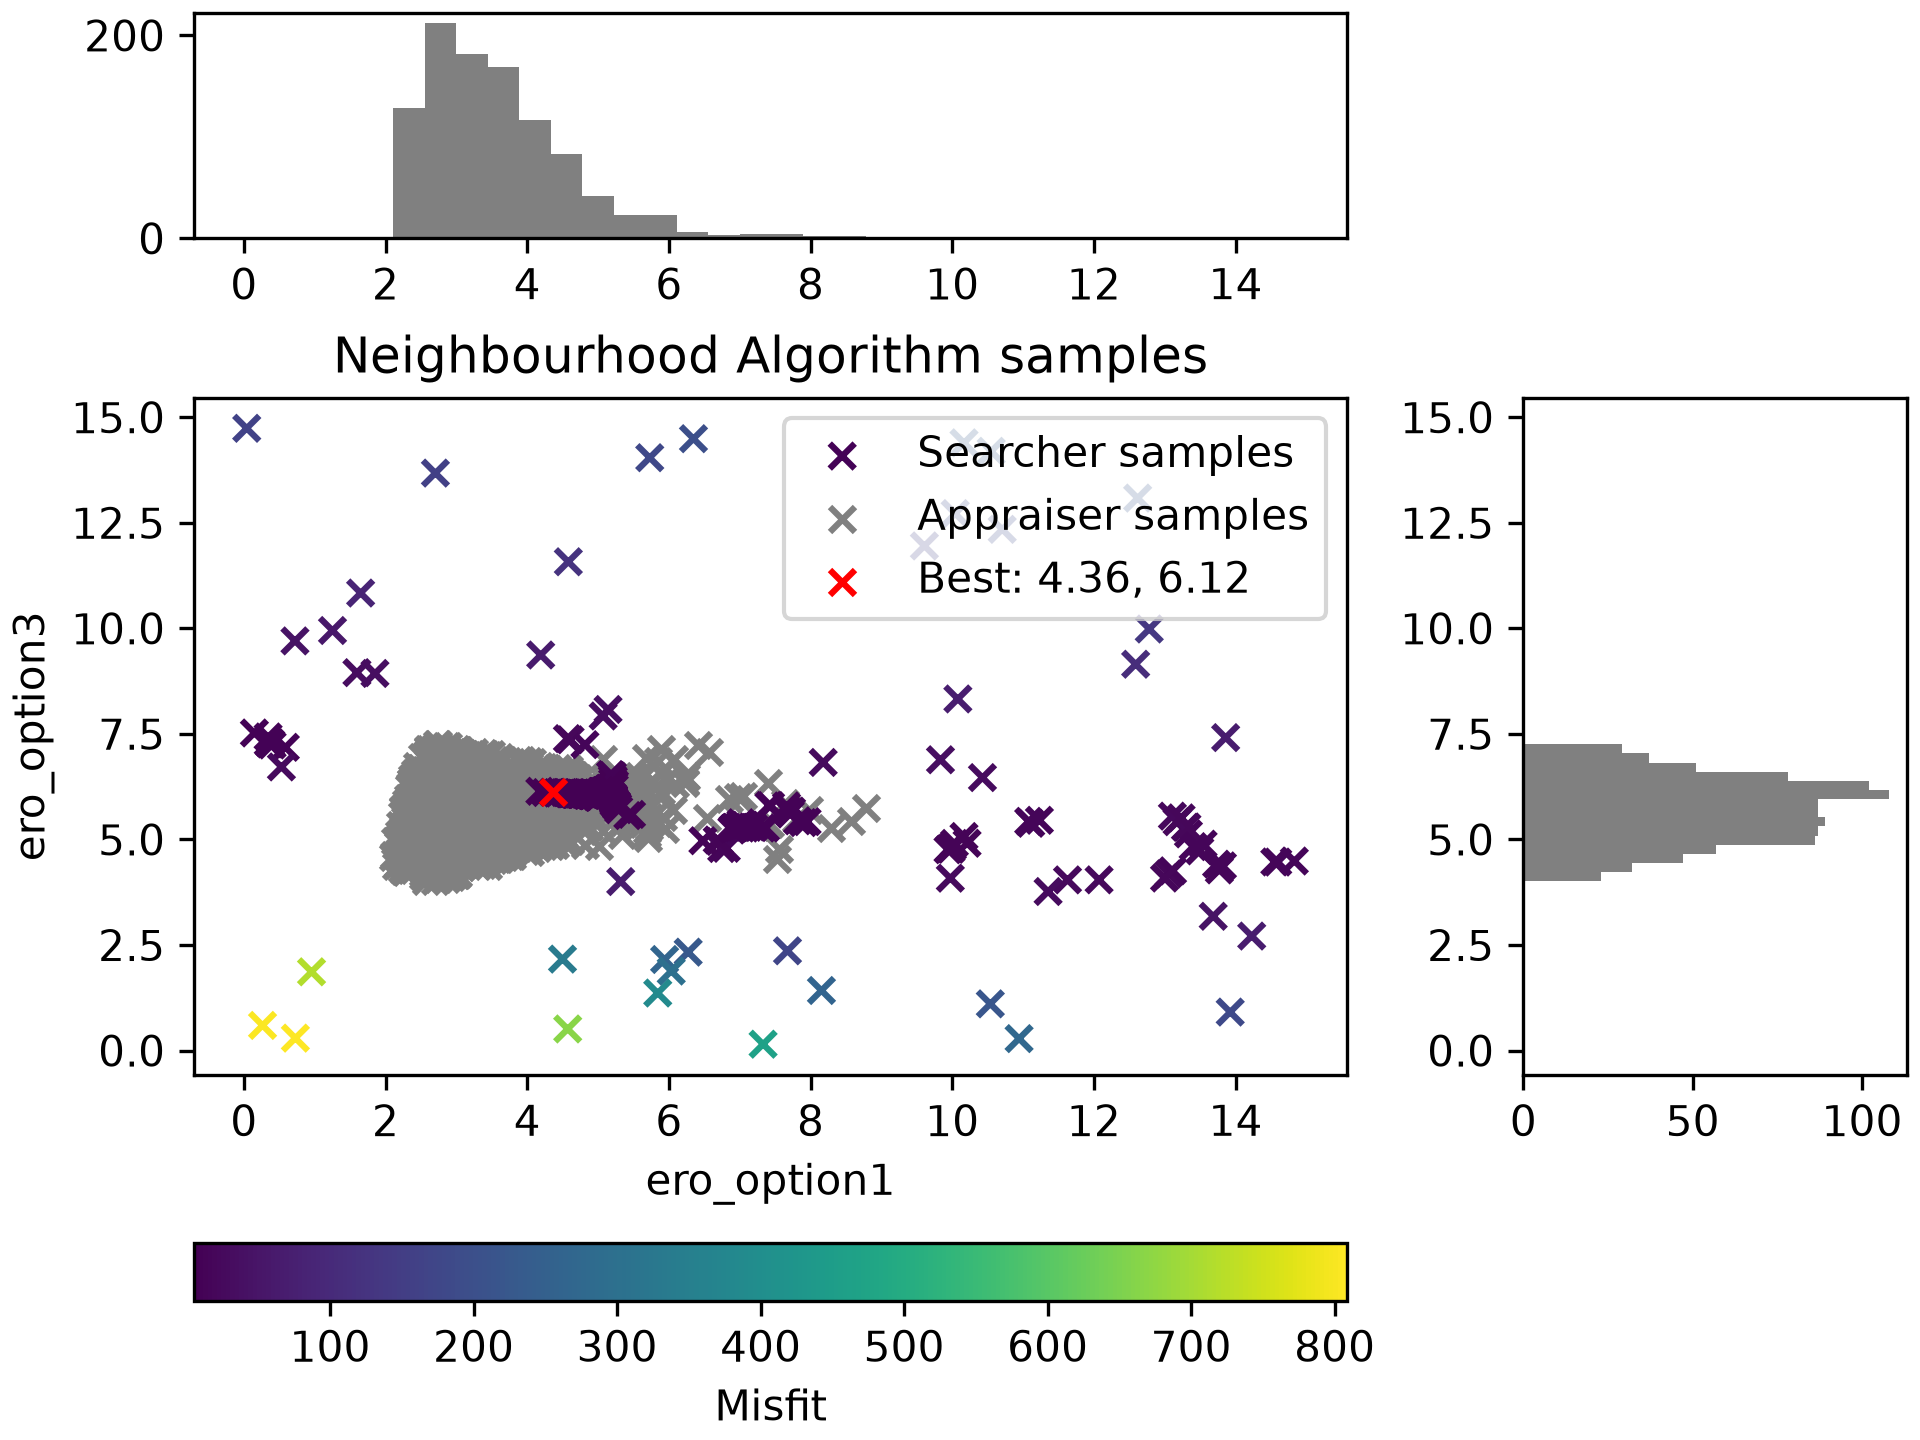

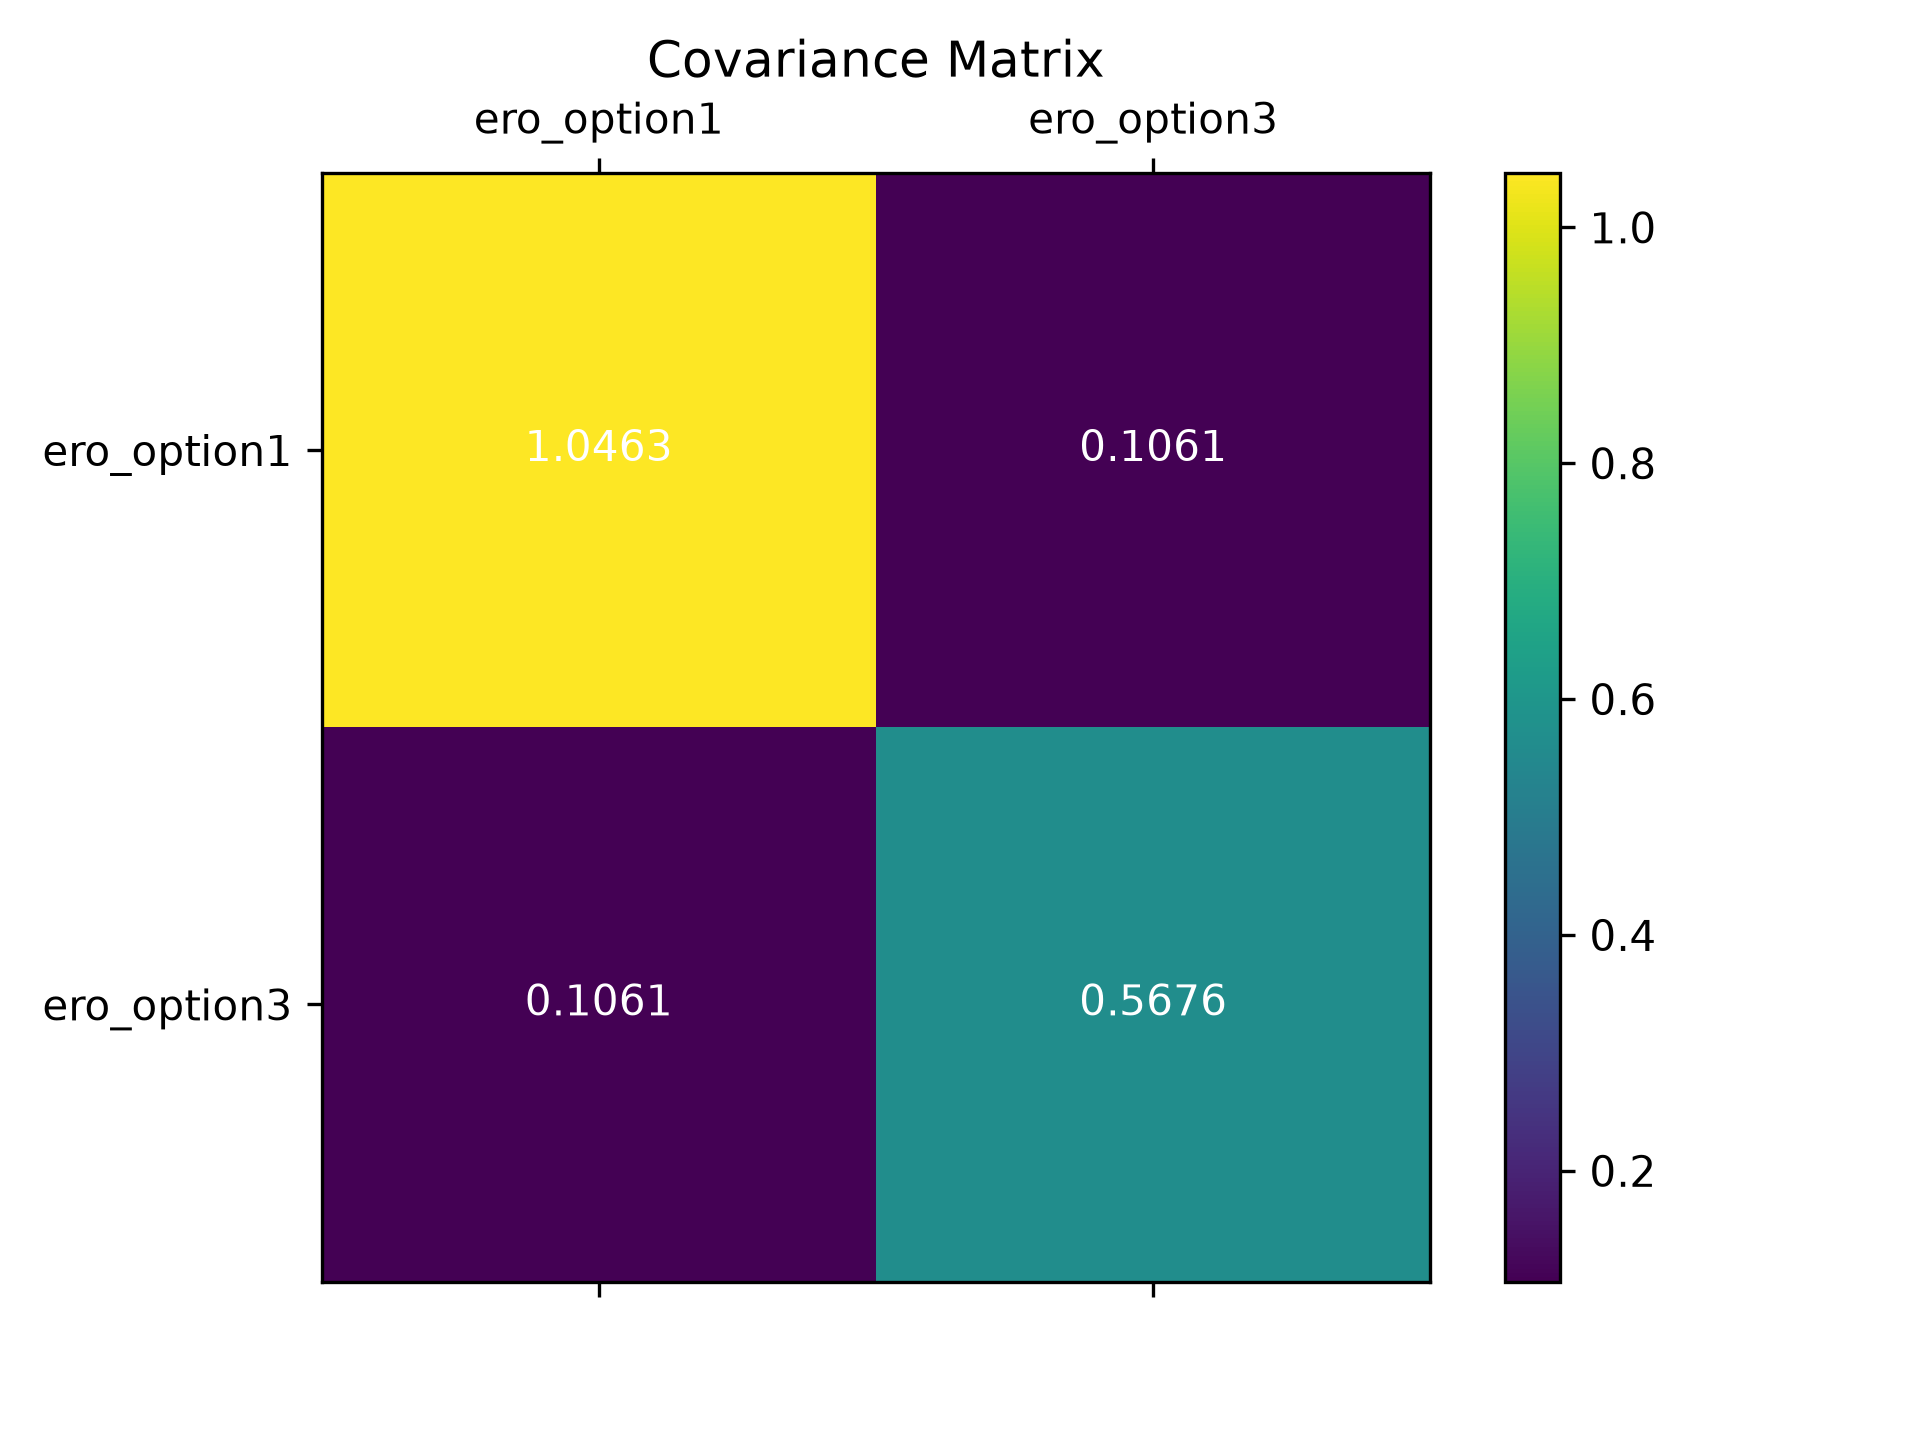

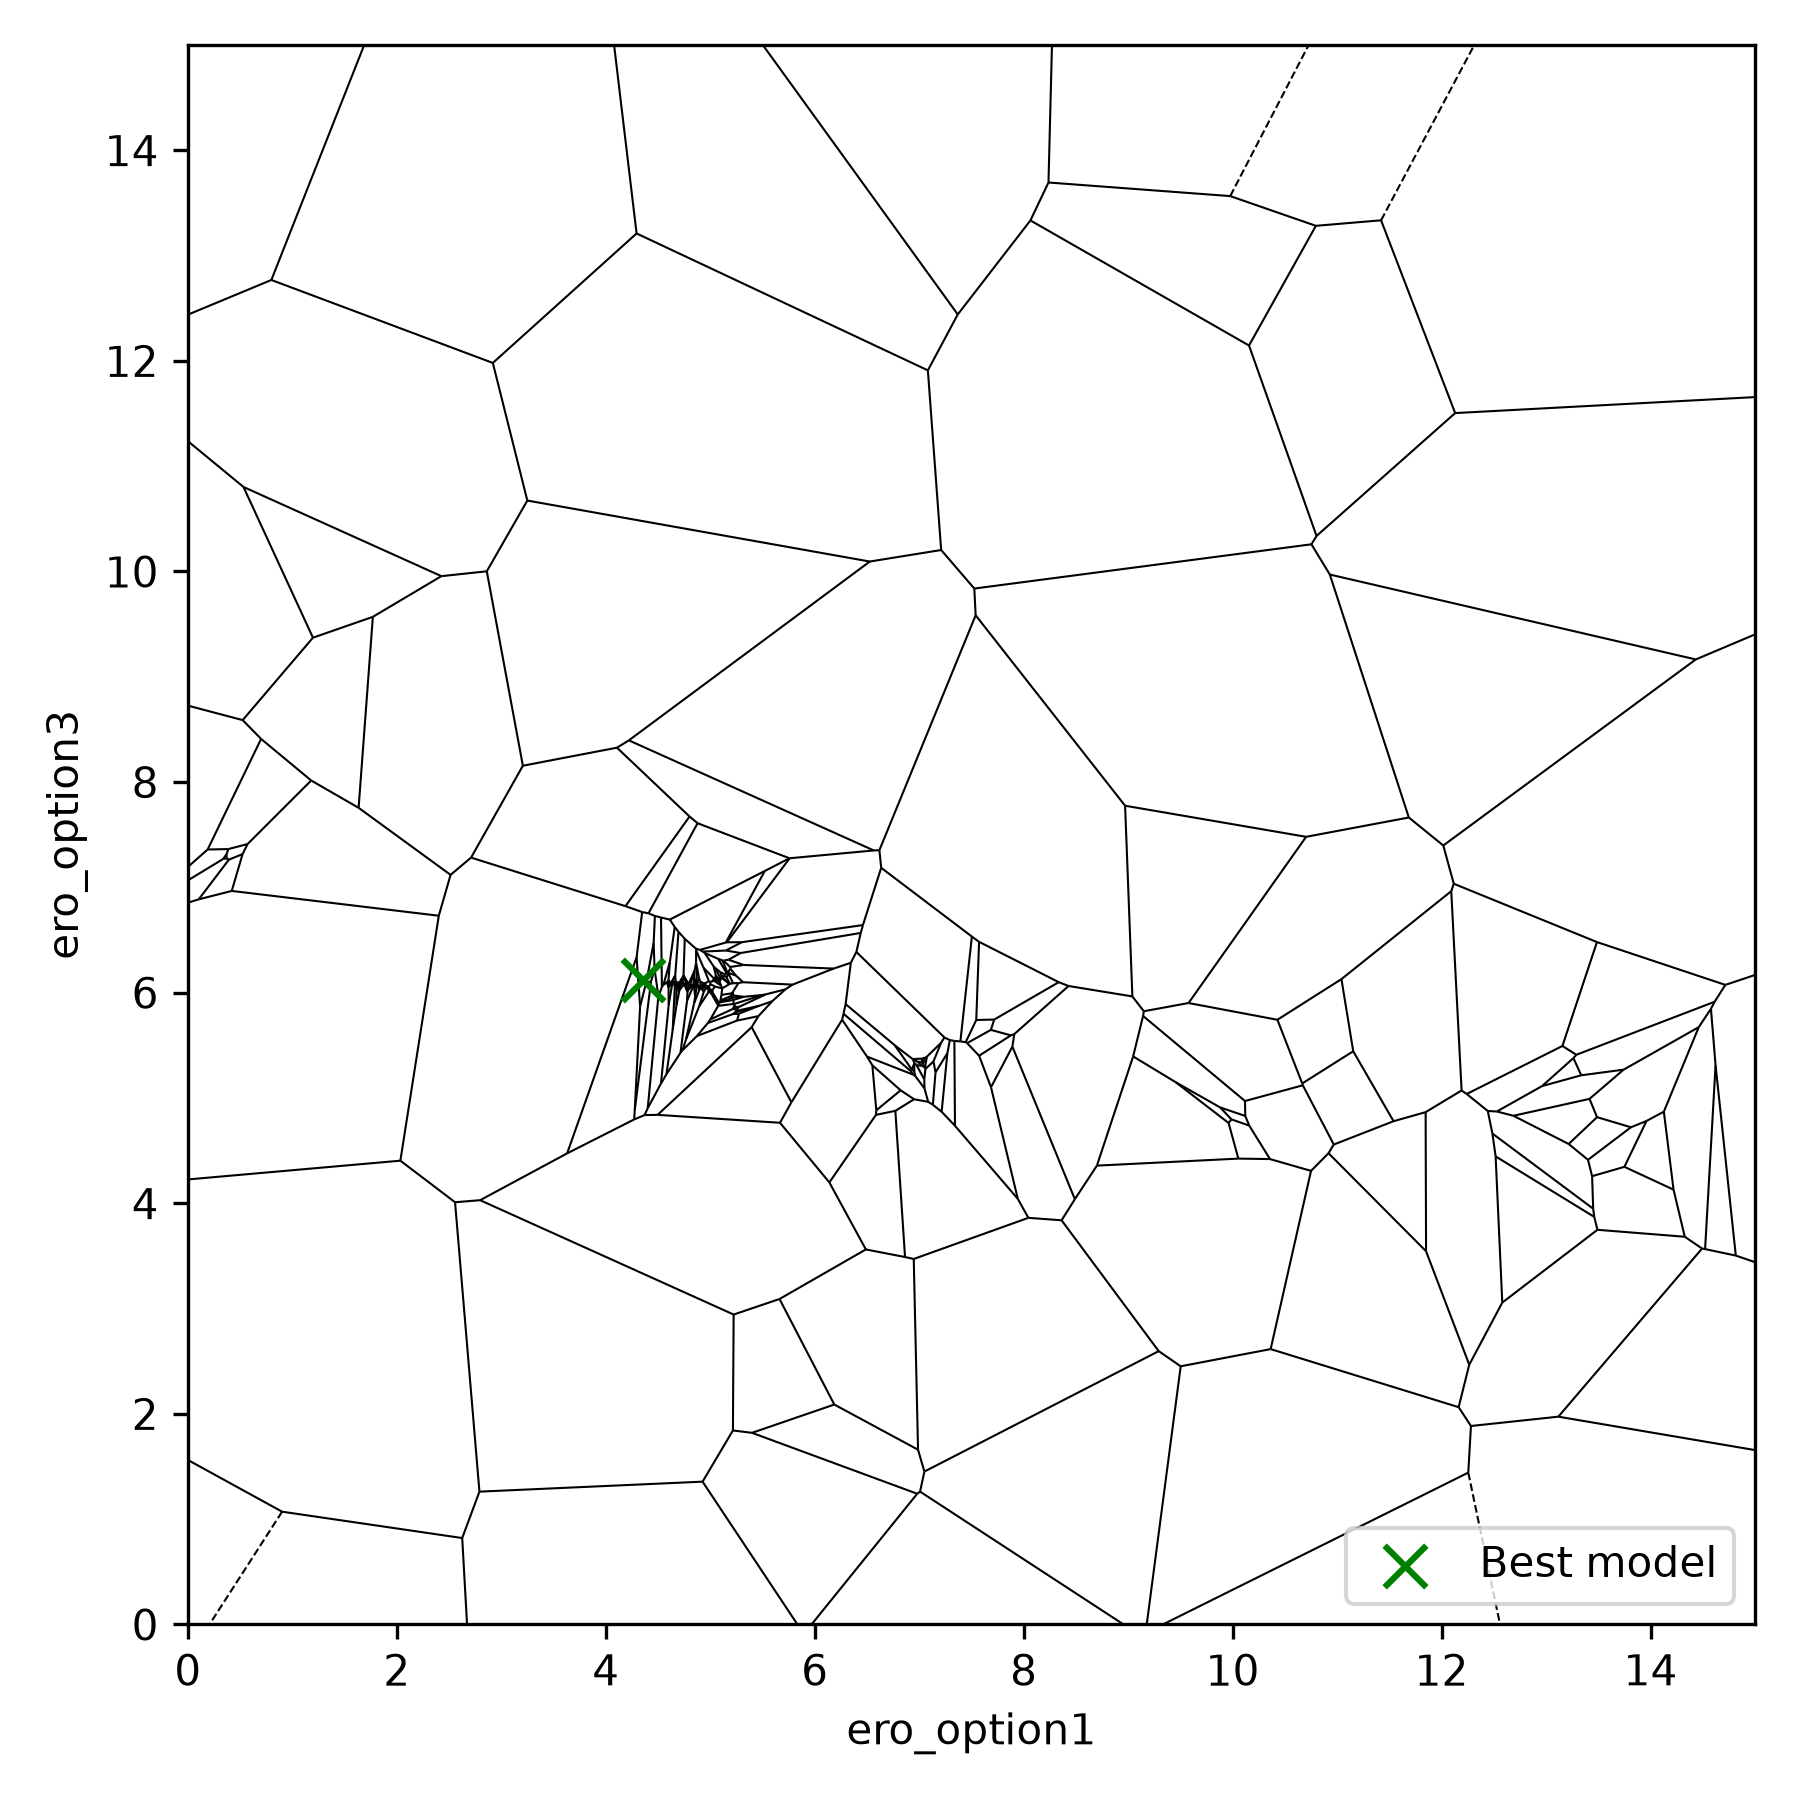

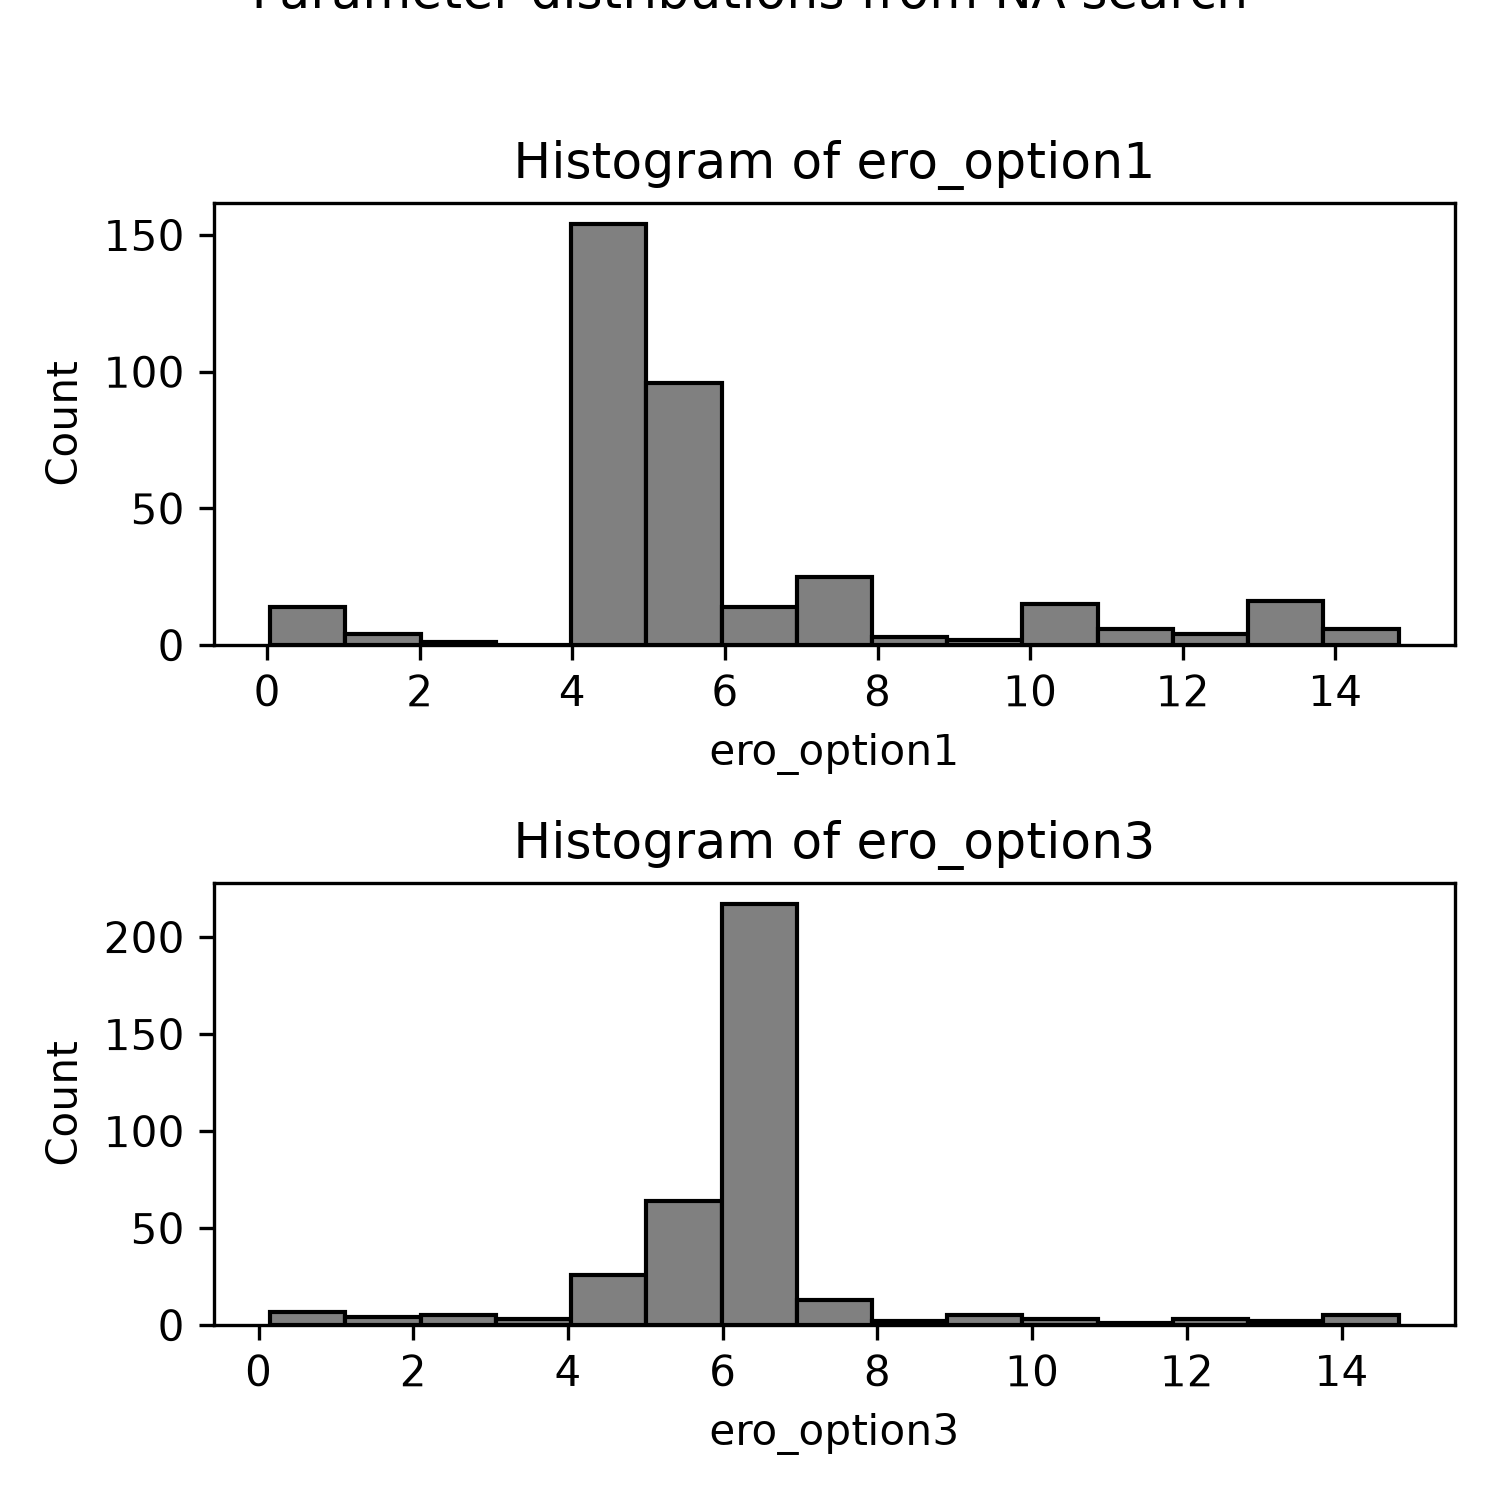

In [48]:
na_plots = [
    "png/na_misfit.png",
    "png/na_samples.png",
    "png/na_covariance_matrix.png",
    "png/na_voronoi.png",
    "png/na_histograms.png",
]

for plot in na_plots:
    display(Image(filename=plot))

## Interpreting the NA results

The figures above provide complementary views of how the Neighbourhood Algorithm explored the model parameter space.

- **Misfit evolution:** The initial random search samples a broad range of models and misfit values. During the neighbourhood-search stage, sampling progressively focuses on regions associated with lower misfit. The best-fitting sampled model is highlighted on the plot.

- **Parameter-space sampling:** The scatter plot shows the combinations of `ero_option1` and `ero_option3` explored during the inversion. The searcher samples identify promising regions of parameter space, whereas the appraiser samples provide a more detailed characterization of these regions.

- **Covariance matrix:** The covariance matrix provides an indication of how the inverted parameters vary together. Non-zero off-diagonal values indicate covariance between model parameters.

- **Voronoi diagram:** The Voronoi cells illustrate the adaptive nature of the Neighbourhood Algorithm. Regions containing favourable models are sampled more densely, producing progressively smaller cells around areas of interest.

- **Parameter distributions:** The histograms show the distributions of parameter values obtained during the NA search and appraisal. Concentrated distributions indicate regions of parameter space that are preferentially sampled by the algorithm.

# Running the MCMC inversion

We can now repeat the inversion using Markov Chain Monte Carlo (MCMC).

The geological model, observed thermochronological dataset, and inverted parameter ranges remain unchanged. Only the inversion method is changed from the Neighbourhood Algorithm to MCMC.

In T<sub>c</sub>1D, the MCMC inversion uses the `emcee` ensemble sampler. The main MCMC settings are defined directly in the YAML input file:

| Parameter | Value | Description |
|---|------:|---|
| `mcmc_nwalkers` |     6 | Number of ensemble walkers |
| `mcmc_nsteps` |   100 | Number of steps performed by each walker |
| `mcmc_discard` |     0 | Number of initial steps discarded before analysis |
| `mcmc_thin` |     1 | Thinning factor applied to the chains |

As for the NA example, these values are intentionally small so that the inversion can be run interactively within this notebook.

To switch from NA to MCMC, we only need to change the `run_type` entry in the YAML configuration from:

    run_type: "na"

to:

    run_type: "mcmc"

The remainder of the model configuration is unchanged.

> **⏱️ Runtime:** The MCMC inversion requires many forward-model evaluations and may take several minutes depending on the computer and notebook environment.

In [49]:
yaml_file = "demo_inversion.yaml"

with open(yaml_file, "r") as file:
    yaml_content = file.read()

yaml_content = yaml_content.replace(
    'run_type: "na"',
    'run_type: "mcmc"',
    1,
)

with open(yaml_file, "w") as file:
    file.write(yaml_content)

print("Inversion method changed from NA to MCMC.")

Inversion method changed from NA to MCMC.


In [50]:
!tc1d-cli --input-file demo_inversion.yaml


========================== This is Tc1D version 0.4.1 ==========================

---------------- Starting MCMC inverse mode (single processor) -----------------

[MCMC] Testing params: {'ero_option1': 12.162317557385219, 'ero_option3': 10.60706048122271}
Misfit: 148.28810821426762
[MCMC] Testing params: {'ero_option1': 1.3366454468836015, 'ero_option3': 7.5086482526818585}
Misfit: 7.200473218155333
[MCMC] Testing params: {'ero_option1': 7.304669857626909, 'ero_option3': 9.140700412243095}
Misfit: 76.67764650736602
[MCMC] Testing params: {'ero_option1': 10.225653709837841, 'ero_option3': 1.7977113206871975}
Misfit: 169.4401851852221
[MCMC] Testing params: {'ero_option1': 9.274068812941882, 'ero_option3': 2.144007644426797}
Misfit: 156.00554540386668
[MCMC] Testing params: {'ero_option1': 11.181310295822133, 'ero_option3': 10.796909269259858}
Misfit: 145.1534753428674
  0%|                                                  | 0/100 [00:00<?, ?it/s][MCMC] Testing params: {'ero_option1': 

# Exploring the MCMC inversion results

The MCMC inversion has now sampled the parameter space defined in the YAML input file using the `emcee` ensemble sampler.

T<sub>c</sub>1D automatically generates several diagnostic plots that can be used to inspect the behaviour of the Markov chains and the resulting posterior parameter distributions:

- **MCMC chains** - show the evolution of each walker through parameter space as a function of sampling step.
- **Corner plot** - summarizes the marginal distributions of the inverted parameters and their joint relationships.
- **Misfit plot** - shows the model misfit associated with the sampled parameter combinations.
- **Negative log-posterior plot** - shows the relative posterior probability of the sampled models.
- **Parameter scatter plot** - shows the sampled combinations of `ero_option1` and `ero_option3`, coloured by model misfit.

For this short demonstration, the MCMC settings are intentionally limited to keep the calculation time manageable. The resulting chains and posterior distributions should therefore be interpreted as an illustration of the MCMC workflow rather than as evidence of a fully converged inversion.

The plots generated by T<sub>c</sub>1D are displayed below.

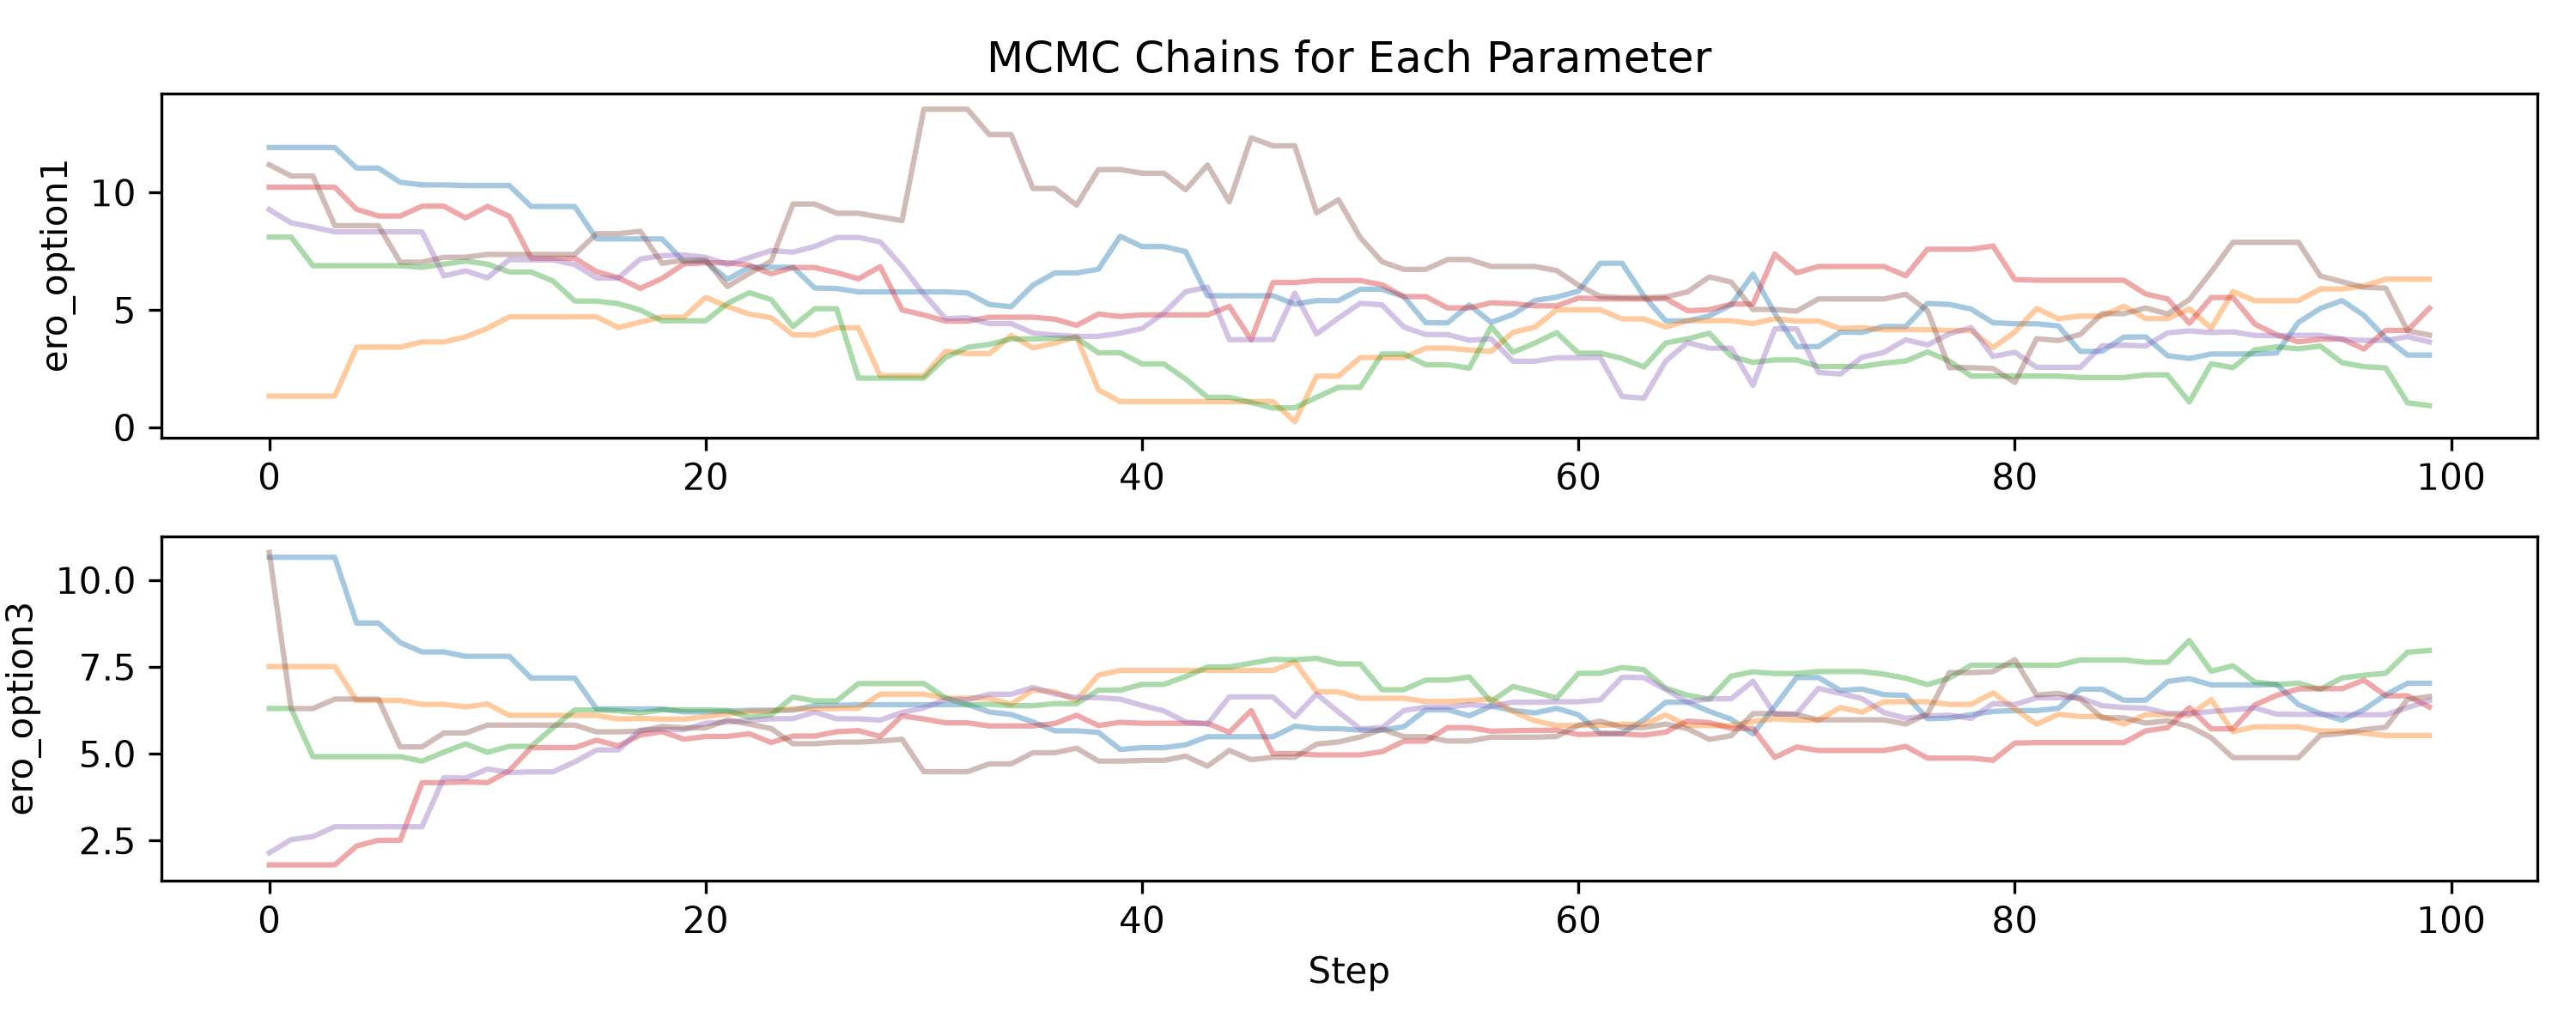

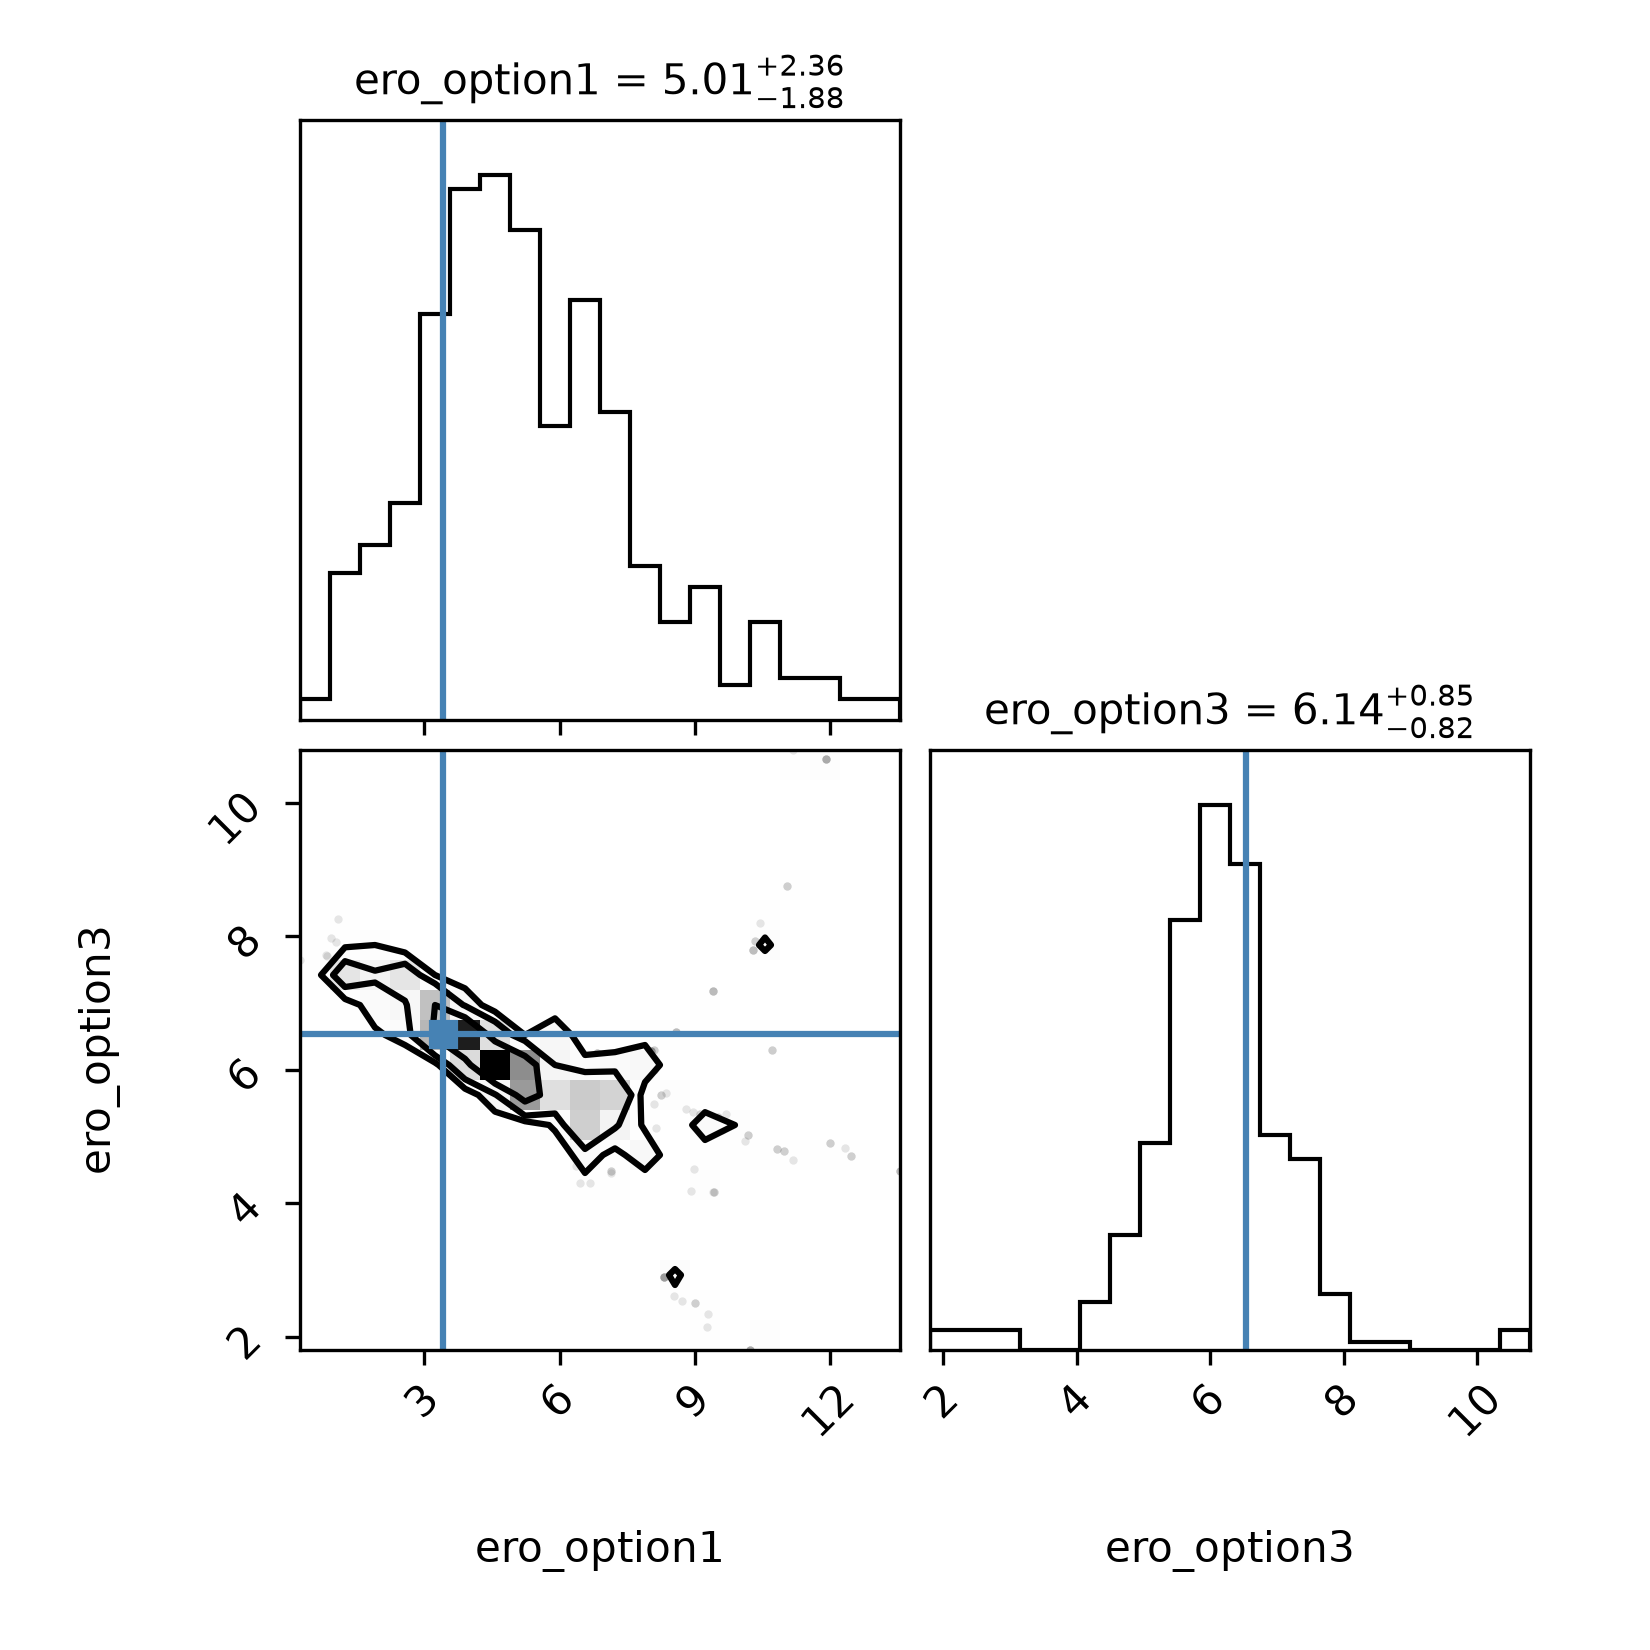

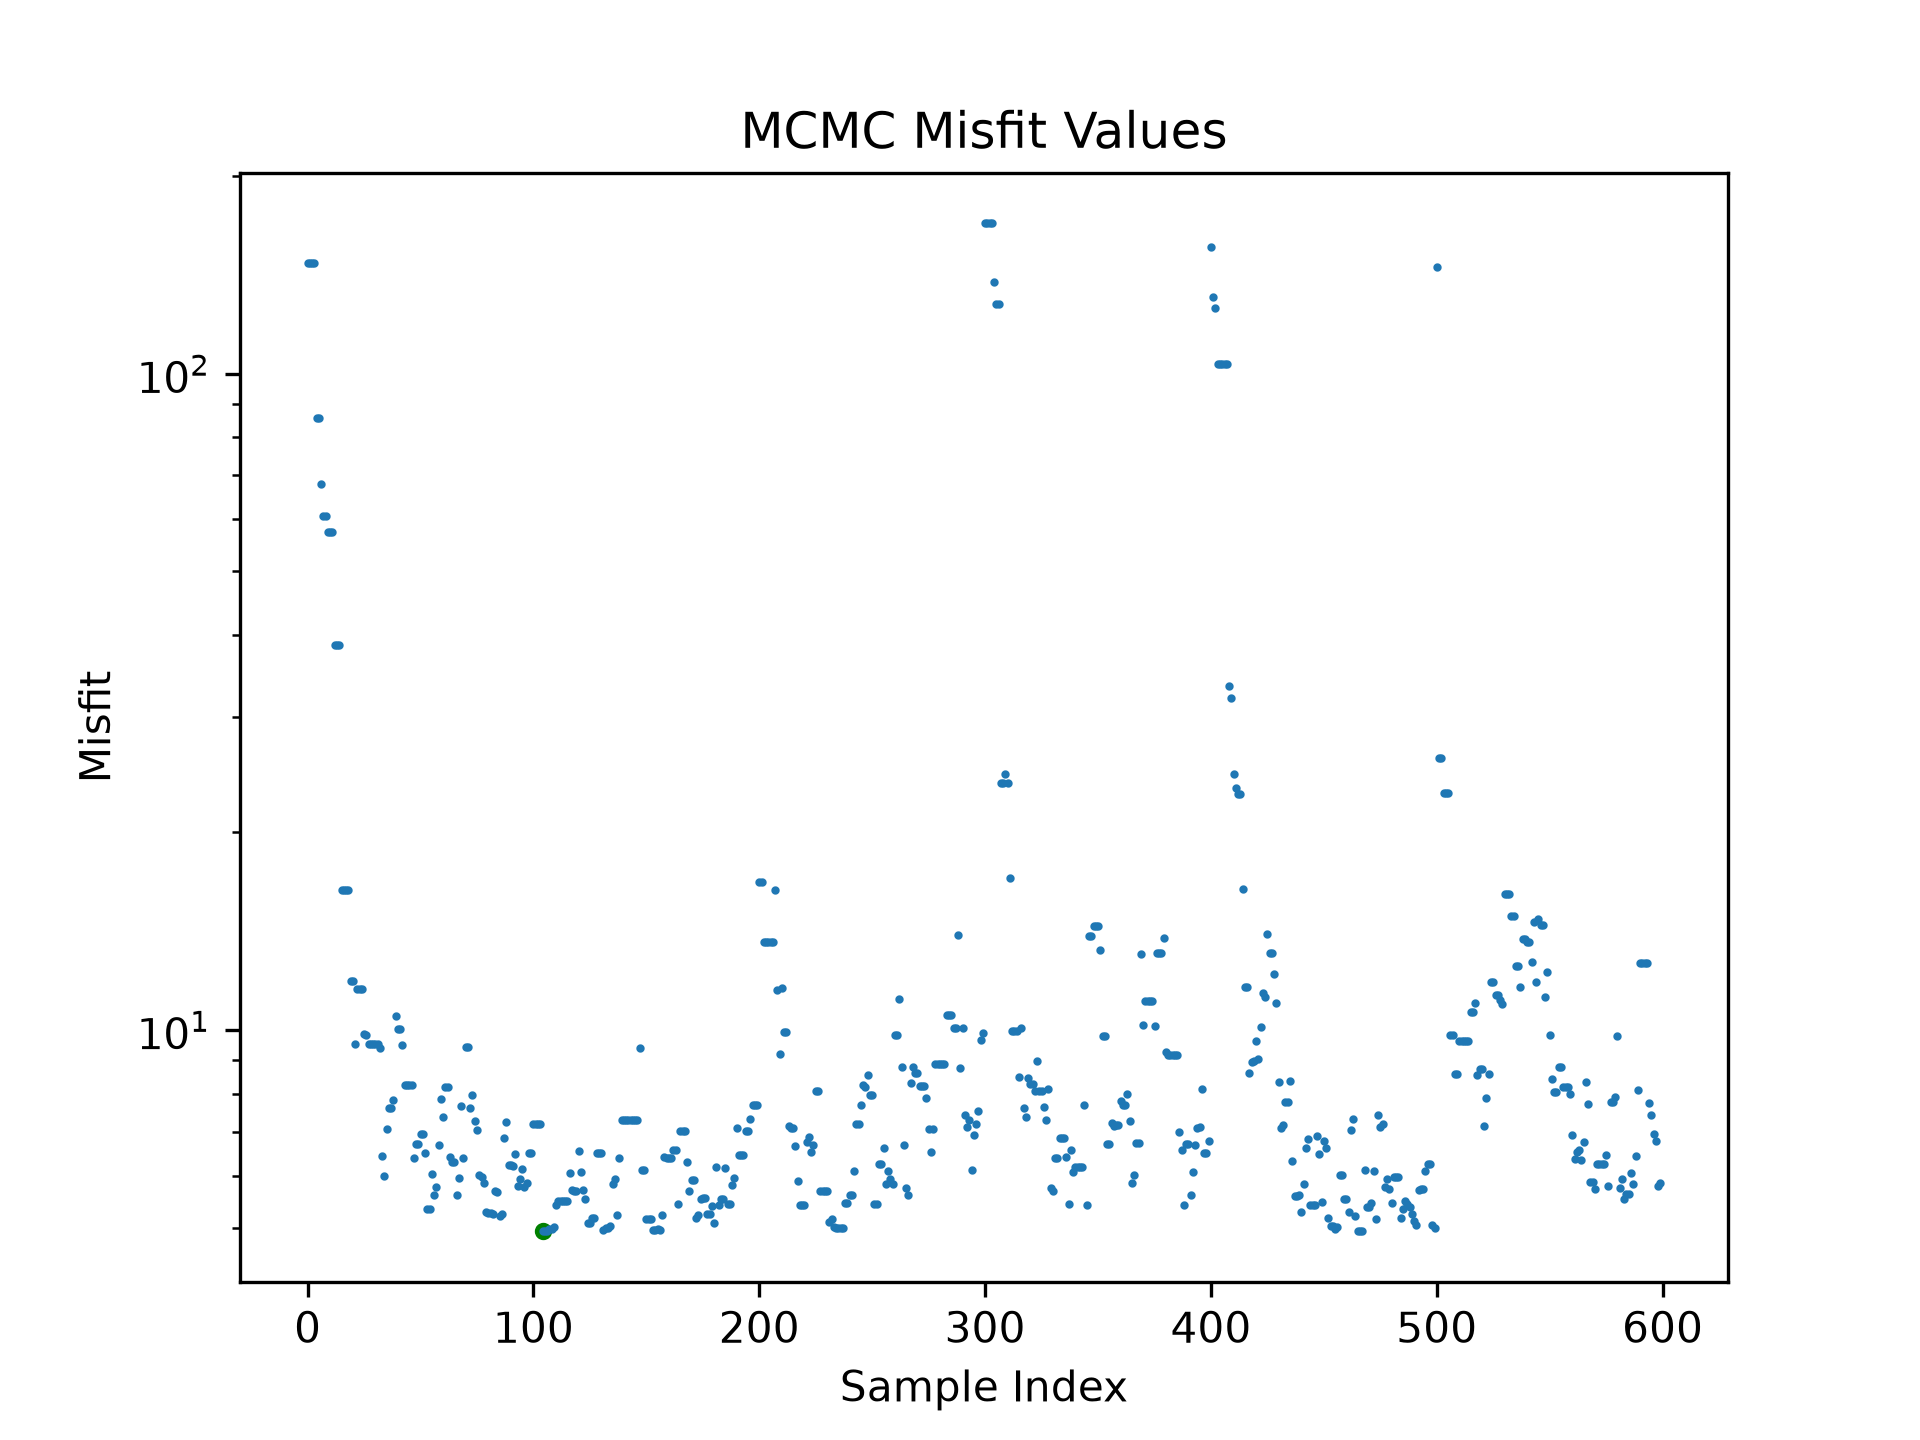

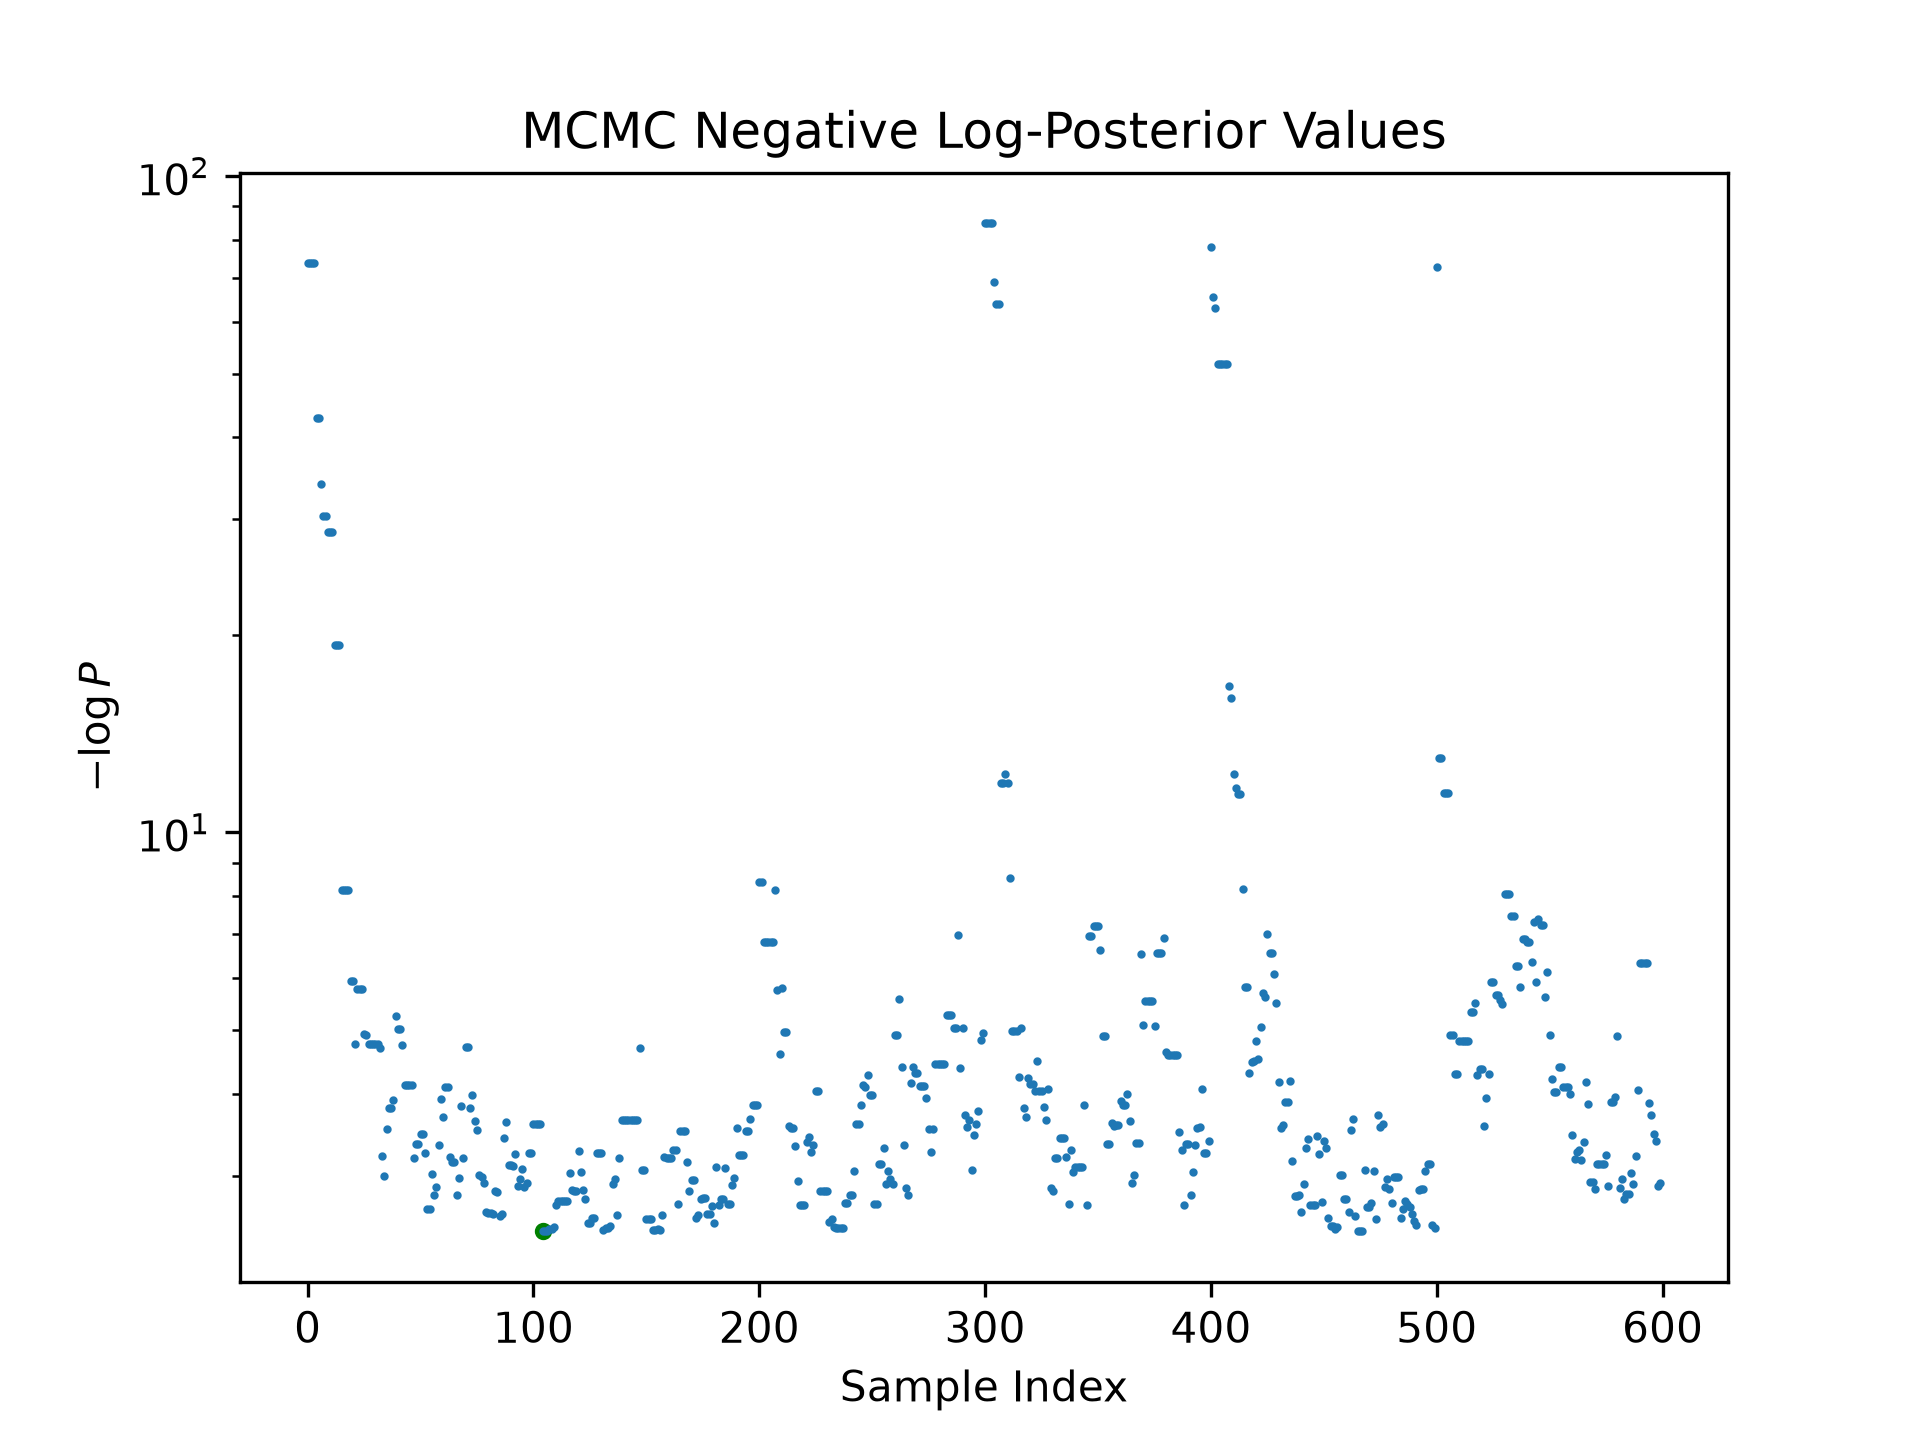

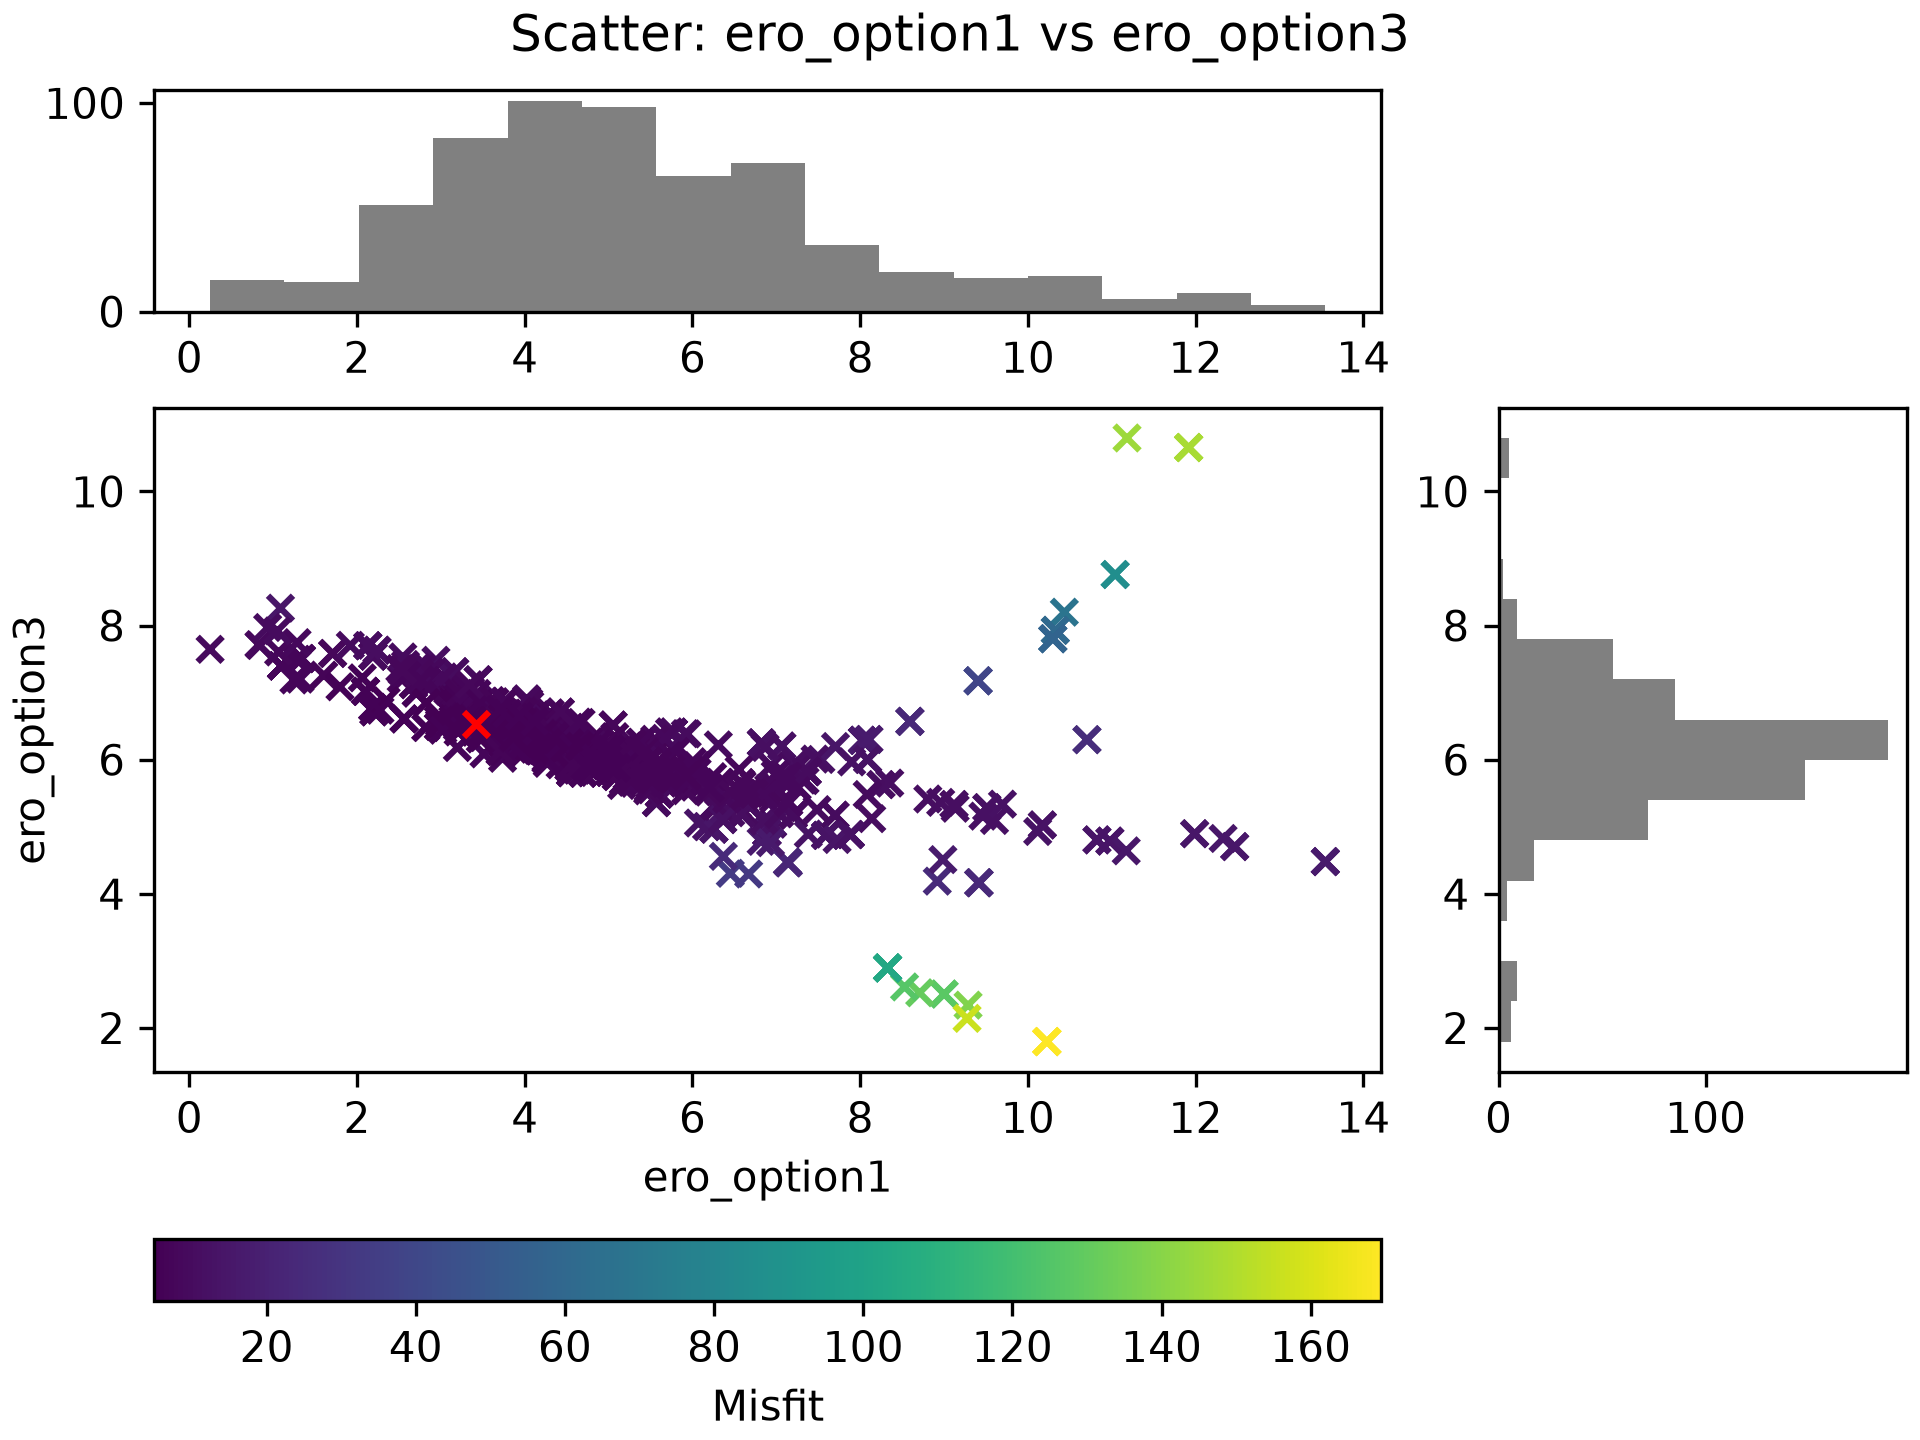

In [52]:
mcmc_plots = [
    "png/mcmc_chains.png",
    "png/mcmc_corner.png",
    "png/mcmc_misfit.png",
    "png/mcmc_neg_log_posterior.png",
    "png/mcmc_scatter_ero_option1_vs_ero_option3.png",
]

for plot in mcmc_plots:
    display(Image(filename=plot))

## Interpreting the MCMC results

The MCMC diagnostic plots provide complementary information about the behaviour of the sampler and the posterior distributions of the inverted parameters.

* **MCMC chains:** The chains show how individual walkers move through parameter space. For a well-sampled posterior, the walkers should explore similar regions without remaining trapped in their initial positions.

* **Corner plot:** The one-dimensional histograms show the marginal posterior distributions of each parameter, whereas the two-dimensional panel illustrates their joint distribution. Elongated or tilted contours indicate correlation between parameters.

* **Misfit and negative log-posterior:** These plots show the relative quality of the sampled models. Lower values correspond to models that provide a better fit to the observations and/or have higher posterior probability.

* **Parameter scatter plot:** The sampled combinations of `ero_option1` and `ero_option3` illustrate the region of parameter space favoured by the inversion. Samples with lower misfit identify combinations that better reproduce the synthetic thermochronological observations.

Because the MCMC run used here is intentionally short, the resulting posterior distributions should not be interpreted as fully converged probability distributions. In scientific applications, longer chains, appropriate burn-in removal, convergence diagnostics, and sufficient effective sampling should be used.


# Summary

In this notebook, we explored the two inversion approaches implemented in T<sub>c</sub>1D:

* the **Neighbourhood Algorithm (NA)**, which adaptively searches the parameter space and preferentially samples regions associated with lower model misfit;
* **Markov Chain Monte Carlo (MCMC)**, which samples the posterior probability distribution of the model parameters.

Both inversions used the same synthetic thermochronological dataset and the same geological model. The model configuration, observations, inversion parameter ranges, and algorithm settings were all defined in a YAML input file.

The complete inversion workflow can therefore be summarized as:

1. define the model and inversion parameters in a YAML file;

2. specify invertible parameters using `[min, max]` ranges;

3. select the inversion method using `run_type`;

4. run T<sub>c</sub>1D with:

   ```
   tc1d-cli --input-file demo_inversion.yaml
   ```

5. inspect the diagnostic plots generated by T<sub>c</sub>1D.

For additional information about model configuration, erosion models, thermochronometer age prediction, and inversion options, please refer to the T<sub>c</sub>1D documentation.
